# Video Game Sales: Exploratory Data Analysis and Visualization

> **University:** Universidade do Vale do Rio dos Sinos (UNISINOS)<br />
> **Program:** Pós-graduação em Inteligência Artificial Aplicada<br />
> **Course:** Processamento e Visualização de Dados em Python<br />
> **Author:** Augusto Stahlschmidt<br />
> **Date:** April 16, 2025  

---

## 1. Introduction & Objectives

**Problem:**  
The video game industry has become the largest entertainment sector by revenue, surpassing film and music combined. Sales patterns vary significantly across platforms, genres, publishers, and geographic regions, and understanding those patterns can help explain what drives commercial success in the market.

**Task Type:**  
Exploratory Data Analysis (EDA) and Data Visualization

**Business Objective:**  
Identify trends and patterns in global video game sales to understand how sales performance relates to platform, genre, publisher, and release year.

**Analytical Goal:**  
Use descriptive statistics and a diverse set of visualizations to characterize the dataset, reveal temporal trends, compare platforms and genres, and examine regional market differences.

**Success Criteria:**
- Characterize the global sales distribution and identify key outliers.
- Determine the top-performing platforms, titles, genres, and publishers.
- Reveal regional differences in genre and platform preference.
- Produce a clean, preprocessed dataset ready for downstream modeling tasks.

## 2. Setup & Imports

In [6]:
import os
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

SEED = 42
np.random.seed(SEED)
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

print("Environment ready")
print("Pandas version:", pd.__version__)

Environment ready
Pandas version: 3.0.1


## 3. Data Loading & Initial Inspection

**Dataset Source:**  
[Kaggle — Video Game Sales](https://www.kaggle.com/datasets/gregorut/videogamesales)

**Description:**  
The dataset contains sales records for over 16,000 video games with more than 100,000 units sold globally. It covers titles released from 1980 through 2016 across multiple platforms and regions.

**Features:**

| # | Feature | Type | Unit | Description |
|---|---------|------|------|-------------|
| 1 | Name | Categorical | — | Title of the game |
| 2 | Platform | Categorical | — | Console or system (e.g., PS2, Wii, X360) |
| 3 | Year | Numeric | Year | Year of release |
| 4 | Genre | Categorical | — | Game genre (e.g., Action, Sports, RPG) |
| 5 | Publisher | Categorical | — | Company that published the game |
| 6 | NA_Sales | Numeric | Millions | Sales in North America |
| 7 | EU_Sales | Numeric | Millions | Sales in Europe |
| 8 | JP_Sales | Numeric | Millions | Sales in Japan |
| 9 | Other_Sales | Numeric | Millions | Sales in all other regions |
| 10 | Global_Sales | Numeric | Millions | Total worldwide sales |

**Unit of Analysis:**  
Each row represents a unique game-platform combination.

**Target Variable:**  
`Global_Sales` — total worldwide unit sales in millions. This is the primary measure of commercial success.

In [14]:
DATA_DIR = os.path.expanduser('~/dataset/')
DATASET_SLUG = 'gregorut/videogamesales'

subprocess.run(
    ['kaggle', 'datasets', 'download', '-d', DATASET_SLUG, '--unzip', '-p', DATA_DIR],
    check=True,
)
print('Dataset downloaded to:', DATA_DIR)

Dataset URL: https://www.kaggle.com/datasets/gregorut/videogamesales
License(s): unknown


  0%|          | 0.00/381k [00:00<?, ?B/s]


Dataset downloaded to: /home/guto/dataset/


100%|██████████| 381k/381k [00:00<00:00, 662kB/s]


In [15]:
df = pd.read_csv("dataset/vgsales.csv")

# Some entries store Year as the string "N/A"; coerce to numeric
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

print("Shape:", df.shape)
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nSummary statistics:")
display(df.describe())

Shape: (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



Data types:


Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


Missing values:


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


Summary statistics:


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 4. Exploratory Data Analysis

Goals of this section:

- Understand the distribution of global sales
- Examine how sales evolved over time
- Identify the best-performing titles, platforms, genres, and publishers
- Compare regional market preferences
- Detect potential outliers before preprocessing

### 4.1 Sales Trends Over Time

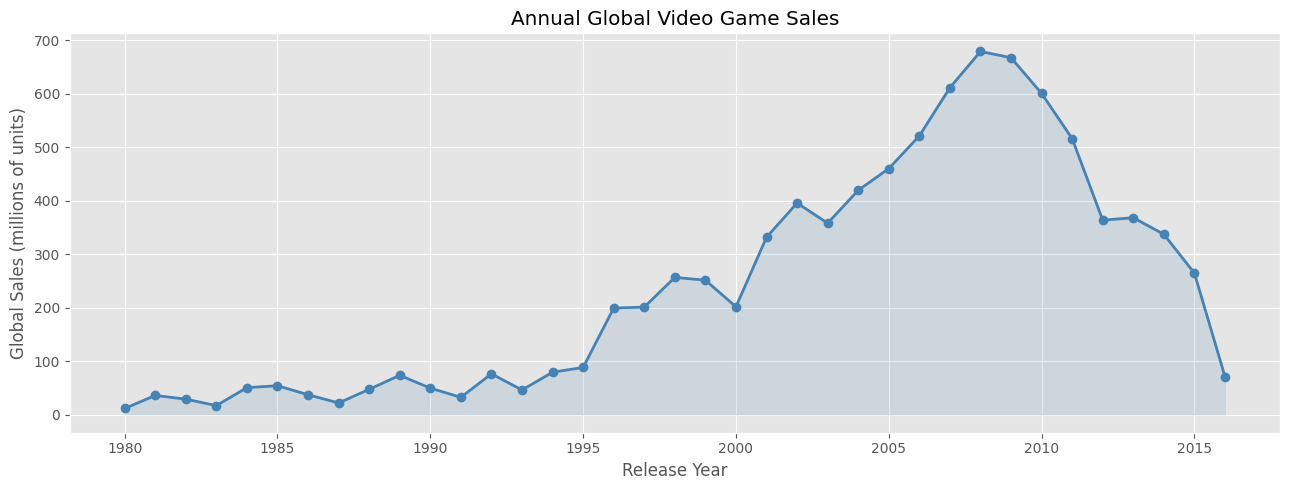

In [16]:
# Aggregate total global sales per year; restrict to the well-covered period
annual_sales = (
    df.groupby("Year")["Global_Sales"]
    .sum()
    .loc[lambda s: (s.index >= 1980) & (s.index <= 2016)]
)

plt.figure(figsize=(13, 5))
plt.plot(annual_sales.index, annual_sales.values, marker="o", linewidth=2, color="steelblue")
plt.fill_between(annual_sales.index, annual_sales.values, alpha=0.15, color="steelblue")
plt.title("Annual Global Video Game Sales")
plt.xlabel("Release Year")
plt.ylabel("Global Sales (millions of units)")
plt.tight_layout()
plt.show()

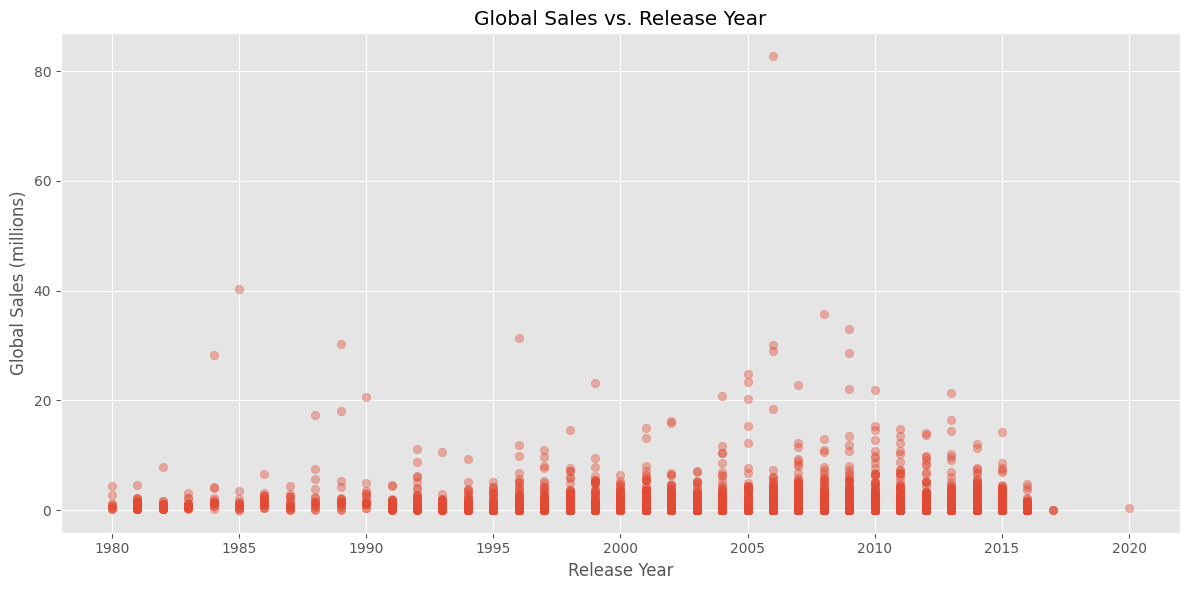

In [17]:
# Scatter: individual titles by release year and global sales
# Reveals how sales are concentrated in specific eras and the presence of outliers
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Year", y="Global_Sales", data=df, alpha=0.4, edgecolor=None)
plt.title("Global Sales vs. Release Year")
plt.xlabel("Release Year")
plt.ylabel("Global Sales (millions)")
plt.tight_layout()
plt.show()

### 4.2 Sales Distribution

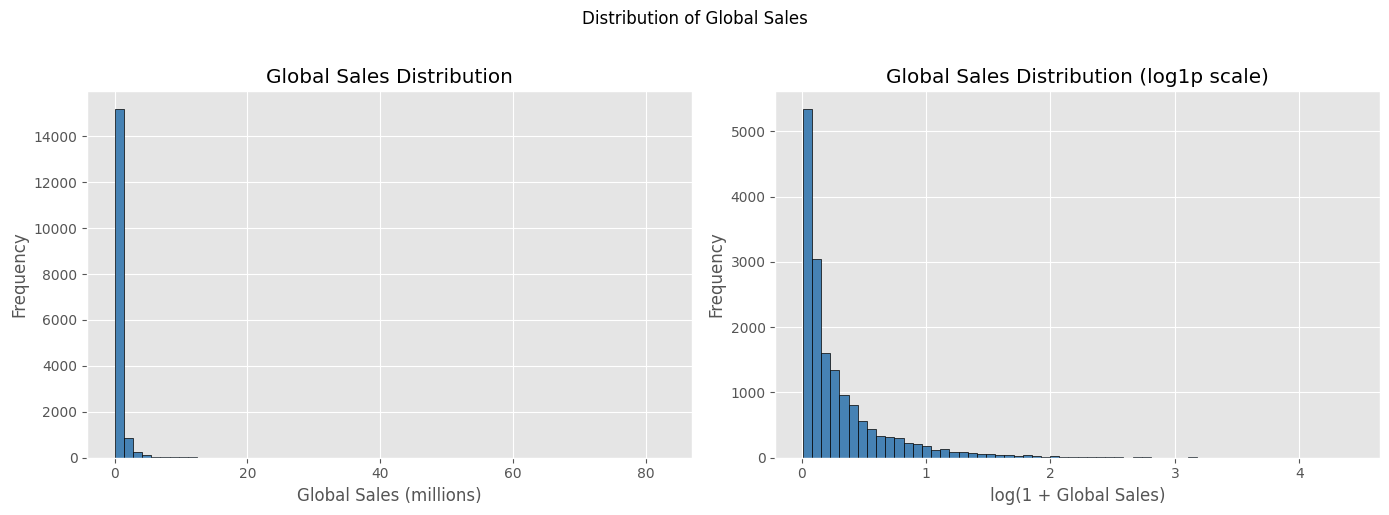

In [18]:
# Global sales is heavily right-skewed; a log transform reveals the underlying shape
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Global_Sales"].dropna(), bins=60, edgecolor="black", color="steelblue")
axes[0].set_title("Global Sales Distribution")
axes[0].set_xlabel("Global Sales (millions)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df["Global_Sales"].dropna()), bins=60, edgecolor="black", color="steelblue")
axes[1].set_title("Global Sales Distribution (log1p scale)")
axes[1].set_xlabel("log(1 + Global Sales)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Distribution of Global Sales", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Top-Performing Titles

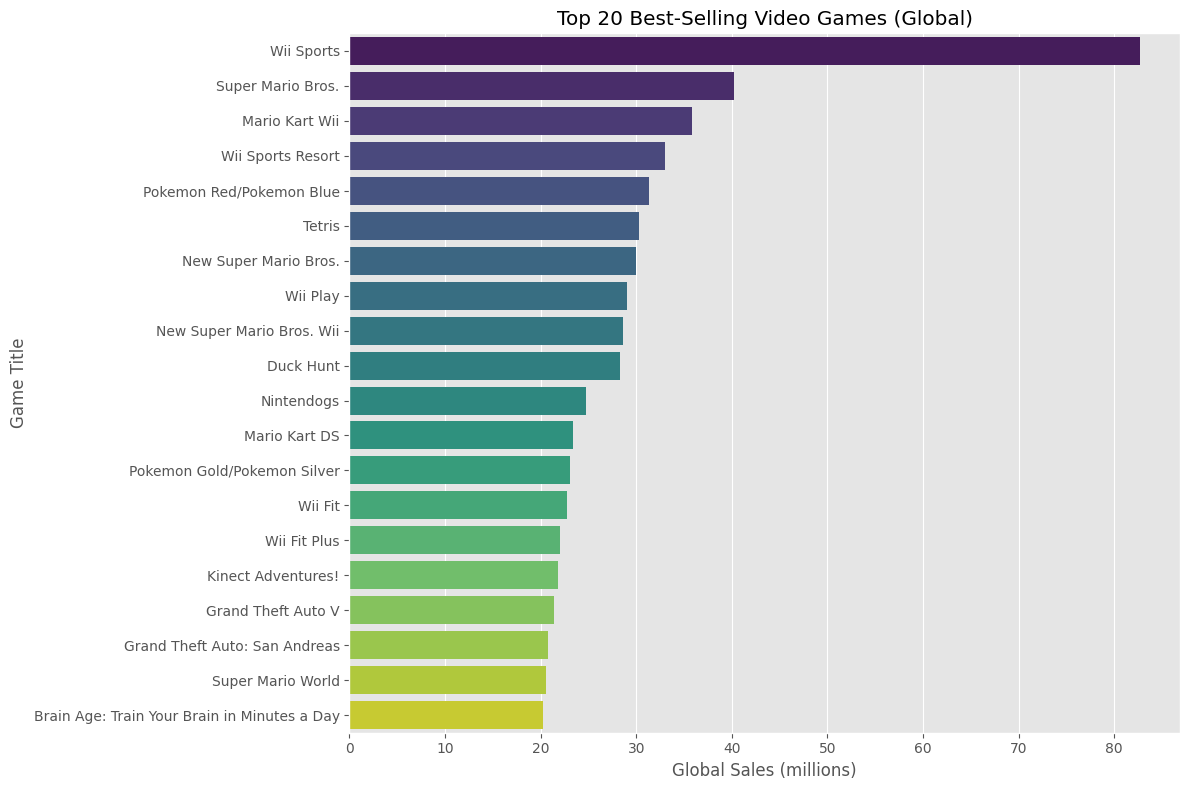

In [19]:
top_20_games = df.nlargest(20, "Global_Sales")[["Name", "Platform", "Genre", "Publisher", "Global_Sales"]]

plt.figure(figsize=(12, 8))
sns.barplot(
    x="Global_Sales", y="Name",
    data=top_20_games,
    hue="Name", palette="viridis", legend=False
)
plt.title("Top 20 Best-Selling Video Games (Global)")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Game Title")
plt.tight_layout()
plt.show()

### 4.4 Platform Analysis

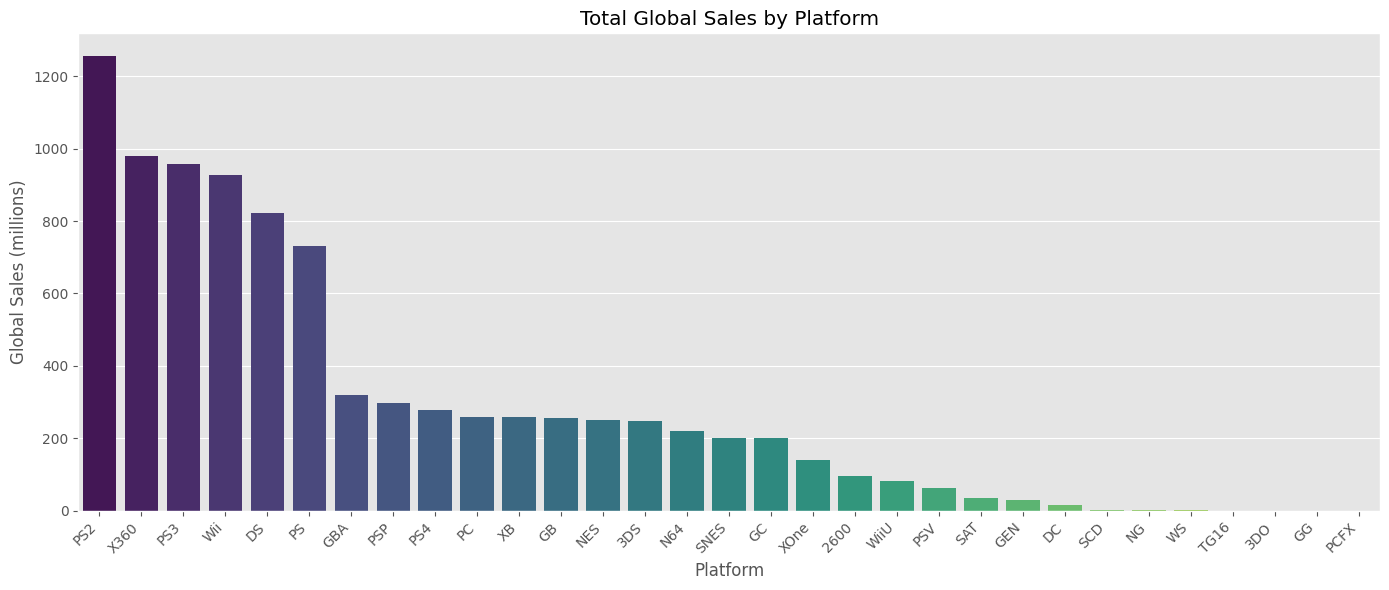

In [20]:
platform_sales = (
    df.groupby("Platform")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
sns.barplot(
    x=platform_sales.index, y=platform_sales.values,
    hue=platform_sales.index, palette="viridis", legend=False
)
plt.title("Total Global Sales by Platform")
plt.xlabel("Platform")
plt.ylabel("Global Sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 4.5 Genre Analysis

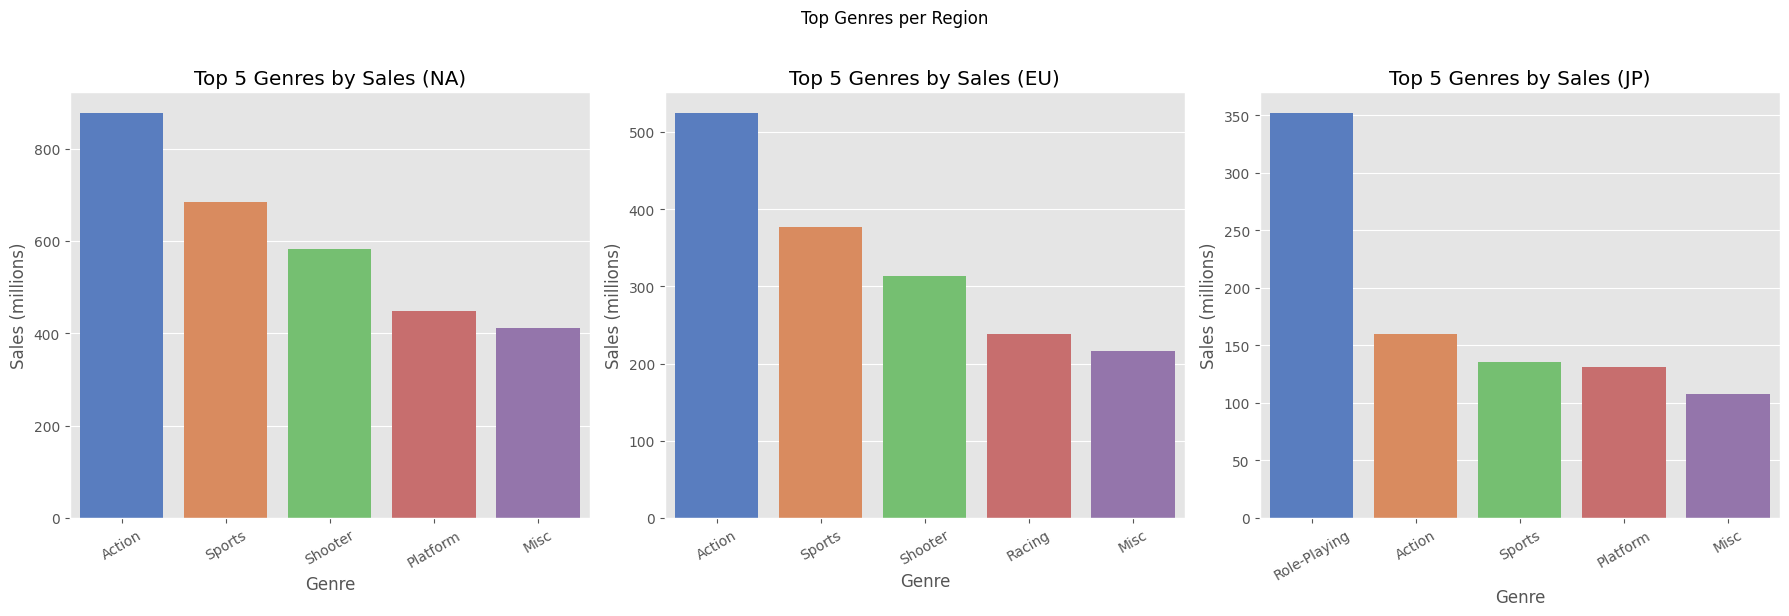

In [21]:
# Top 5 genres by sales in each major region
regions = {"NA": "NA_Sales", "EU": "EU_Sales", "JP": "JP_Sales"}
top_n = 5

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (region_label, col) in zip(axes, regions.items()):
    top_genres = df.groupby("Genre")[col].sum().sort_values(ascending=False).head(top_n)
    sns.barplot(
        x=top_genres.index, y=top_genres.values,
        hue=top_genres.index, palette="muted", legend=False, ax=ax
    )
    ax.set_title(f"Top {top_n} Genres by Sales ({region_label})")
    ax.set_xlabel("Genre")
    ax.set_ylabel("Sales (millions)")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Top Genres per Region", y=1.02)
plt.tight_layout()
plt.show()

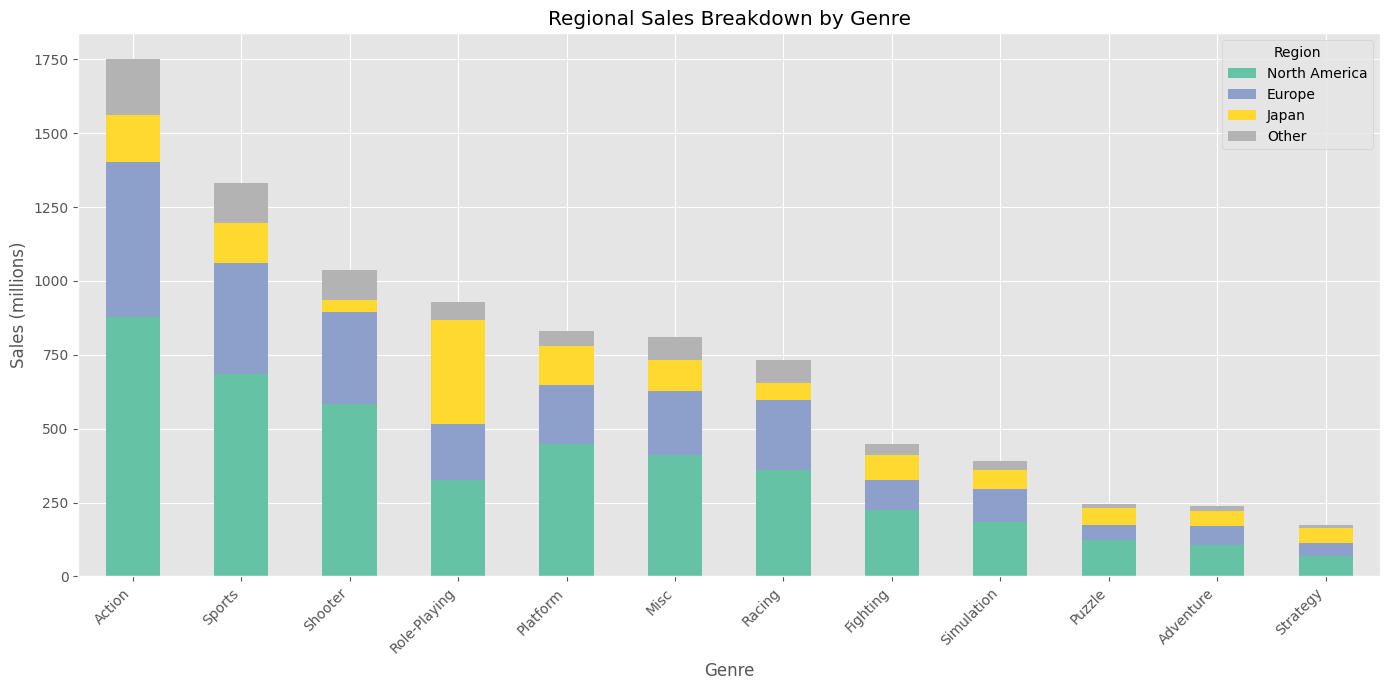

In [22]:
# Stacked bar: regional breakdown of sales by genre
regional_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
genre_regional = (
    df.groupby("Genre")[regional_cols]
    .sum()
    .loc[lambda d: d.sum(axis=1).sort_values(ascending=False).index]
)

genre_regional.plot(
    kind="bar", stacked=True,
    figsize=(14, 7), colormap="Set2"
)
plt.title("Regional Sales Breakdown by Genre")
plt.xlabel("Genre")
plt.ylabel("Sales (millions)")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Region",
    labels=["North America", "Europe", "Japan", "Other"]
)
plt.tight_layout()
plt.show()

### 4.6 Publisher Analysis

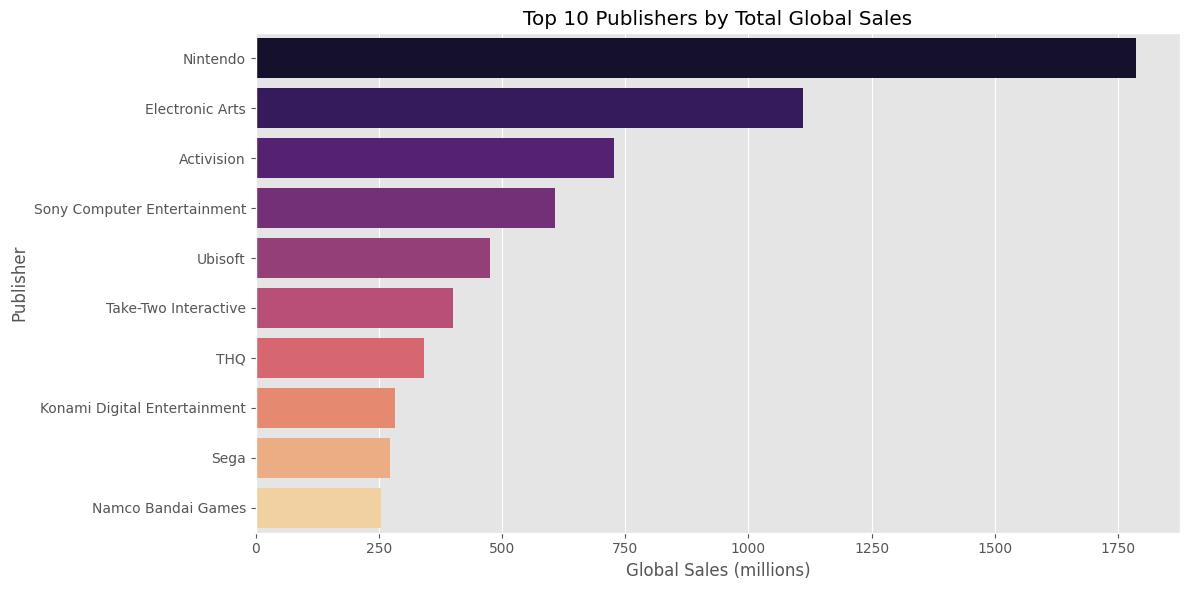

In [23]:
top_publishers_sales = (
    df.groupby("Publisher")["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_publishers_sales.values, y=top_publishers_sales.index,
    hue=top_publishers_sales.index, palette="magma", legend=False
)
plt.title("Top 10 Publishers by Total Global Sales")
plt.xlabel("Global Sales (millions)")
plt.ylabel("Publisher")
plt.tight_layout()
plt.show()

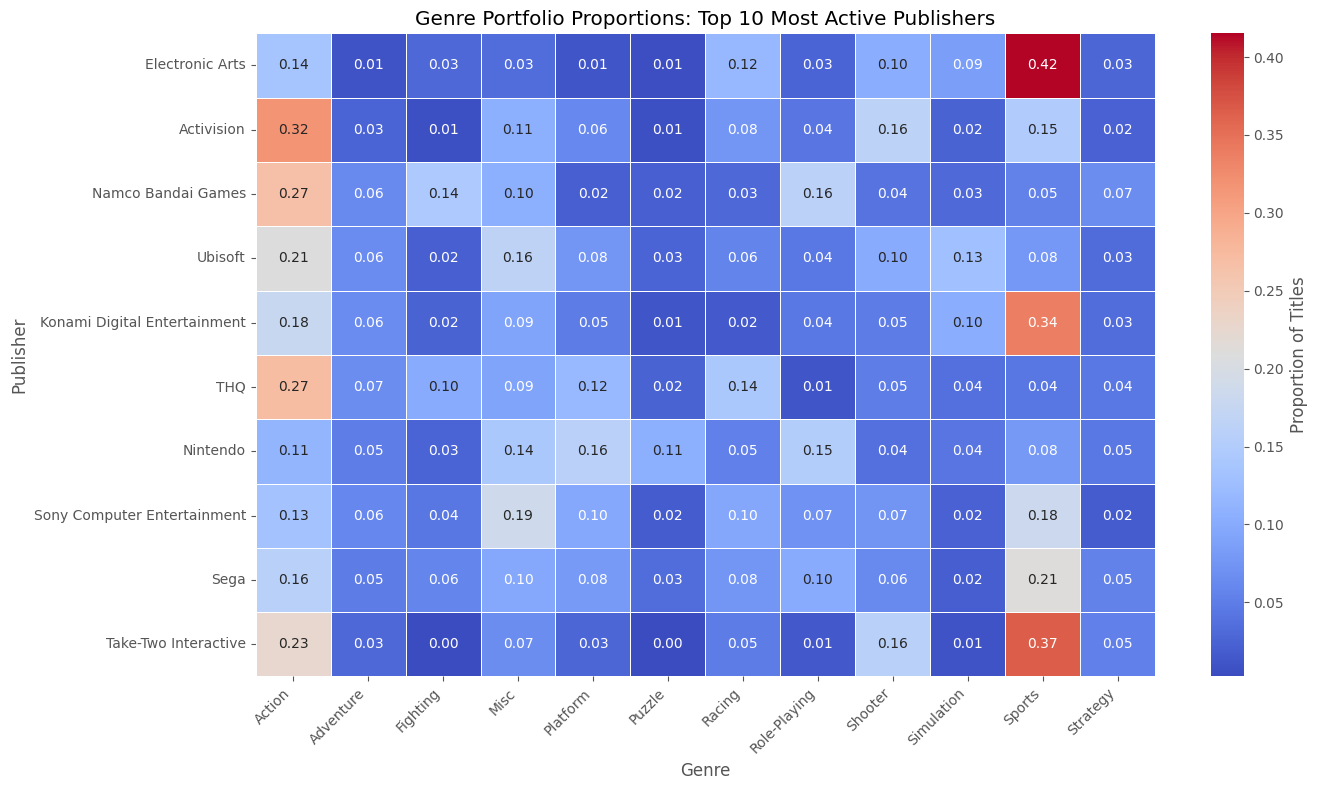

In [24]:
# Genre portfolio breakdown for the 10 most active publishers (by title count)
top_10_publishers_by_count = df["Publisher"].value_counts().head(10).index

publisher_genre_counts = (
    df.groupby(["Publisher", "Genre"])
    .size()
    .unstack(fill_value=0)
    .loc[top_10_publishers_by_count]
)

# Normalize to proportions for comparability across publishers of different sizes
publisher_genre_props = publisher_genre_counts.div(publisher_genre_counts.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    publisher_genre_props,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    cbar_kws={"label": "Proportion of Titles"},
    linewidths=0.5
)
plt.title("Genre Portfolio Proportions: Top 10 Most Active Publishers")
plt.xlabel("Genre")
plt.ylabel("Publisher")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 4.7 Regional Sales Correlations

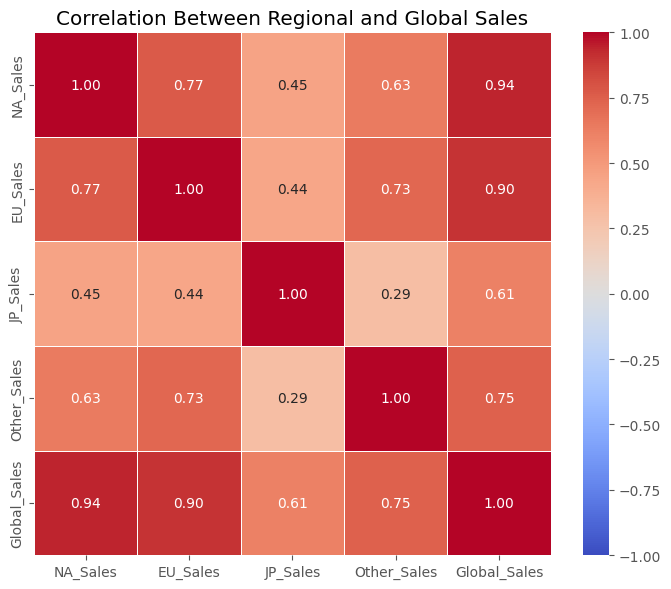

In [25]:
# Pairwise correlations between regional sales columns
# A low correlation for Japan suggests it follows a distinct market pattern
regional_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    df[regional_cols].corr(),
    annot=True, fmt=".2f",
    cmap="coolwarm", vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Correlation Between Regional and Global Sales")
plt.tight_layout()
plt.show()

## 5. Preprocessing & Feature Engineering

Operations performed:

- Removing rows with missing `Year` or `Publisher` values
- Converting `Year` from float to integer after cleaning
- Detecting and removing outliers in `Global_Sales` using the IQR method
- One-hot encoding of categorical features (`Genre`, `Platform`, `Publisher`) for potential downstream modeling

All steps are applied to the full dataset without a train/test split, since this project is exploratory in nature.

In [26]:
# Drop rows with missing Year or Publisher, which are required for analysis
df_clean = df.dropna(subset=["Year", "Publisher"]).copy()
df_clean["Year"] = df_clean["Year"].astype(int)

print(f"Rows before cleaning:  {len(df)}")
print(f"Rows after cleaning:   {len(df_clean)}")
print(f"Rows removed:          {len(df) - len(df_clean)}")

Rows before cleaning:  16598
Rows after cleaning:   16291
Rows removed:          307


In [27]:
# IQR-based outlier detection for Global_Sales
Q1 = df_clean["Global_Sales"].quantile(0.25)
Q3 = df_clean["Global_Sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = (
    (df_clean["Global_Sales"] < lower_bound) |
    (df_clean["Global_Sales"] > upper_bound)
).sum()

print(f"Q1: {Q1:.4f}  Q3: {Q3:.4f}  IQR: {IQR:.4f}")
print(f"Lower bound: {lower_bound:.4f}   Upper bound: {upper_bound:.4f}")
print(f"\nOutliers detected: {n_outliers}")

df_no_outliers = df_clean[
    (df_clean["Global_Sales"] >= lower_bound) &
    (df_clean["Global_Sales"] <= upper_bound)
].copy()

print(f"\nRows before outlier removal: {len(df_clean)}")
print(f"Rows after outlier removal:  {len(df_no_outliers)}")

Q1: 0.0600  Q3: 0.4800  IQR: 0.4200
Lower bound: -0.5700   Upper bound: 1.1100

Outliers detected: 1826

Rows before outlier removal: 16291
Rows after outlier removal:  14465


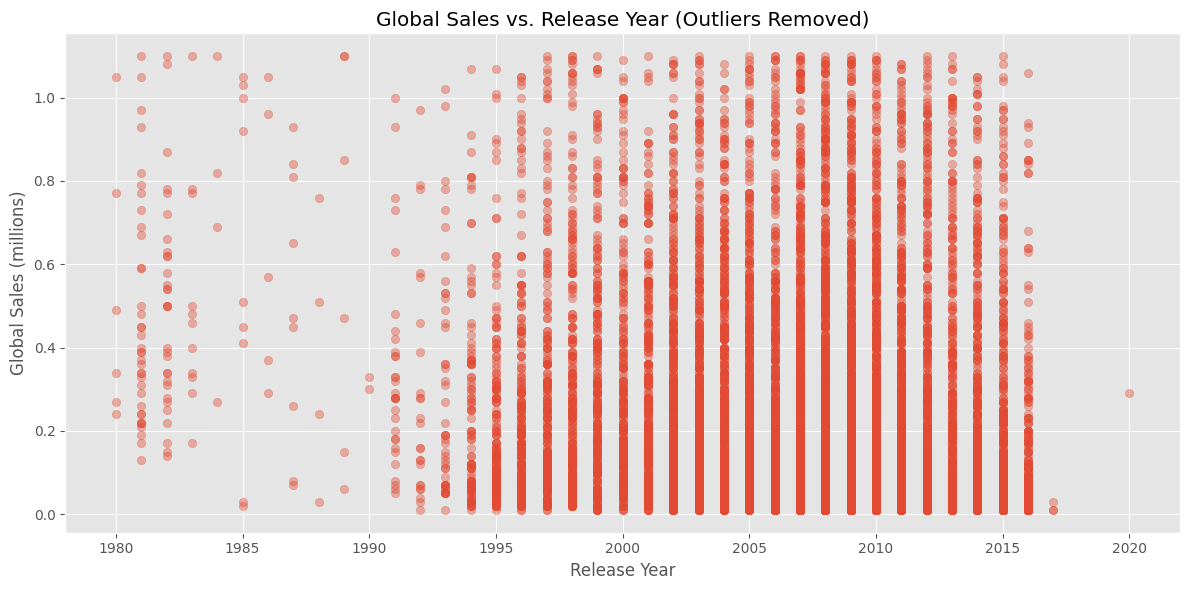

In [28]:
# Scatter plot after outlier removal shows a denser, more interpretable distribution
plt.figure(figsize=(12, 6))
sns.scatterplot(x="Year", y="Global_Sales", data=df_no_outliers, alpha=0.4, edgecolor=None)
plt.title("Global Sales vs. Release Year (Outliers Removed)")
plt.xlabel("Release Year")
plt.ylabel("Global Sales (millions)")
plt.tight_layout()
plt.show()

In [29]:
# One-hot encode categorical features for downstream ML tasks
# drop_first=True avoids multicollinearity
df_encoded = pd.get_dummies(
    df_no_outliers,
    columns=["Genre", "Platform", "Publisher"],
    drop_first=True
)

print(f"Shape before encoding: {df_no_outliers.shape}")
print(f"Shape after encoding:  {df_encoded.shape}")
display(df_encoded.head())

Shape before encoding: (14465, 11)
Shape after encoding:  (14465, 616)


,Rank,Name,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Genre_Adventure,Genre_Fighting,Genre_Misc,Genre_Platform,Genre_Puzzle,Genre_Racing,Genre_Role-Playing,Genre_Shooter,Genre_Simulation,Genre_Sports,Genre_Strategy,Platform_3DO,Platform_3DS,Platform_DC,Platform_DS,Platform_GB,Platform_GBA,Platform_GC,Platform_GEN,Platform_GG,Platform_N64,Platform_NES,Platform_NG,Platform_PC,Platform_PCFX,Platform_PS,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_SAT,Platform_SCD,Platform_SNES,Platform_TG16,Platform_WS,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Publisher_1C Company,Publisher_20th Century Fox Video Games,Publisher_2D Boy,Publisher_3DO,Publisher_49Games,Publisher_505 Games,Publisher_5pb,Publisher_7G//AMES,Publisher_989 Sports,Publisher_989 Studios,Publisher_AQ Interactive,Publisher_ASC Games,Publisher_ASCII Entertainment,Publisher_ASCII Media Works,Publisher_ASK,Publisher_Abylight,Publisher_Acclaim Entertainment,Publisher_Accolade,Publisher_Ackkstudios,Publisher_Acquire,Publisher_Activision,Publisher_Activision Blizzard,Publisher_Activision Value,Publisher_Adeline Software,Publisher_Aerosoft,Publisher_Agatsuma Entertainment,Publisher_Agetec,Publisher_Aksys Games,Publisher_Alawar Entertainment,Publisher_Alchemist,Publisher_Alternative Software,Publisher_Altron,Publisher_Alvion,Publisher_American Softworks,Publisher_Angel Studios,Publisher_Answer Software,Publisher_Aqua Plus,Publisher_Aques,Publisher_Arc System Works,Publisher_Aria,Publisher_Arika,Publisher_ArtDink,Publisher_Aruze Corp,Publisher_Ascaron Entertainment,Publisher_Ascaron Entertainment GmbH,Publisher_Asgard,Publisher_Asmik Ace Entertainment,Publisher_Asmik Corp,Publisher_Aspyr,Publisher_Astragon,Publisher_Asylum Entertainment,Publisher_Atari,Publisher_Athena,Publisher_Atlus,Publisher_Avalon Interactive,Publisher_Avanquest,Publisher_Avanquest Software,Publisher_Axela,Publisher_BAM! Entertainment,Publisher_BMG Interactive Entertainment,Publisher_BPS,Publisher_Banpresto,Publisher_Benesse,Publisher_Berkeley,Publisher_Bethesda Softworks,Publisher_Big Ben Interactive,Publisher_Big Fish Games,Publisher_Bigben Interactive,Publisher_Black Bean Games,Publisher_Blast! Entertainment Ltd,Publisher_Blue Byte,Publisher_Bohemia Interactive,Publisher_Bomb,Publisher_Boost On,Publisher_Brash Entertainment,Publisher_Broccoli,Publisher_BushiRoad,Publisher_CBS Electronics,Publisher_CCP,Publisher_CDV Software Entertainment,Publisher_CPG Products,Publisher_CTO SpA,Publisher_Capcom,Publisher_Cave,Publisher_ChunSoft,Publisher_City Interactive,Publisher_Cloud Imperium Games Corporation,Publisher_Coconuts Japan,Publisher_Codemasters,Publisher_Codemasters Online,Publisher_CokeM Interactive,Publisher_Coleco,Publisher_Comfort,Publisher_Commseed,Publisher_Compile,Publisher_Compile Heart,Publisher_Conspiracy Entertainment,Publisher_Core Design Ltd.,Publisher_Crave Entertainment,Publisher_Creative Core,Publisher_Crimson Cow,Publisher_Crystal Dynamics,Publisher_Culture Brain,Publisher_Culture Publishers,Publisher_CyberFront,Publisher_Cygames,Publisher_D3Publisher,Publisher_DHM Interactive,Publisher_DSI Games,Publisher_DTP Entertainment,Publisher_Daedalic,Publisher_Daedalic Entertainment,Publisher_Daito,Publisher_Data Age,Publisher_Data Design Interactive,Publisher_Data East,Publisher_Datam Polystar,Publisher_Deep Silver,"Publisher_Destination Software, Inc",Publisher_Destineer,Publisher_Detn8 Games,Publisher_Devolver Digital,Publisher_DigiCube,Publisher_Disney Interactive Studios,Publisher_Dorart,Publisher_DreamCatcher Interactive,Publisher_DreamWorks Interactive,Publisher_Dusenberry Martin Racing,Publisher_EA Games,Publisher_EON Digital Entertainment,Publisher_ESP,Publisher_Easy Interactive,Publisher_Ecole,Publisher_Edia,Publisher_Eidos Interactive,Publisher_Electronic Arts,Publisher_Electronic Arts Victor,Publisher_Elf,Publisher_Elite,Publisher_Empire Interactive,Publisher_Encore,Publisher_Enix Corporation,Publisher_Enjoy Gaming ltd.,Pub

## 6. Conclusions & Next Steps

**Key Findings**

- The dataset contains 16,598 game-platform records across 11 features, with sales data complete for all rows. Only Year (271 missing, 1.6%) and Publisher (58 missing, 0.35%) have gaps.
- Global sales are extremely right-skewed: the mean is 0.54 million units, the median is 0.17 million, and the maximum is 82.74 million (Wii Sports). The 75th percentile sits at 0.47 million, meaning three-quarters of the catalog sold fewer than 470,000 copies.
- All five best-selling titles in the dataset are published by Nintendo: Wii Sports (82.74M), Super Mario Bros. (40.24M), Mario Kart Wii (35.82M), Wii Sports Resort (33.00M), and Pokemon Red/Pokemon Blue (31.37M). This points to a strong concentration of blockbuster performance in a single publisher's first-party catalog.
- IQR analysis set the outlier upper bound at 1.11M units (Q1=0.06, Q3=0.48, IQR=0.42). A total of 1,826 records exceeded this threshold, representing approximately 11.2% of the cleaned dataset.
- After removing rows with missing Year or Publisher (307 rows) and flagged outliers (1,826 rows), the clean dataset has 14,465 records. One-hot encoding of Genre, Platform, and Publisher expanded the feature space from 11 columns to 616.

**Analysis vs Success Criteria**

- The global sales distribution was fully characterized: data is heavily right-skewed, with a small number of blockbusters dominating aggregate figures.
- Top-performing titles, platforms, genres, and publishers were identified and visualized across seven EDA subsections (4.1 through 4.7).
- Regional market differences were examined through per-region genre rankings and a stacked bar chart, complemented by a correlation heatmap of regional sales.
- A clean, preprocessed dataset of 14,465 records was produced with all categorical variables encoded into 616 binary features, satisfying the stated goal of preparing data for downstream modeling tasks.

**Interpretation**

- The extreme concentration at the top of the sales distribution (Wii Sports at 82.74M vs. a median of 0.17M) reflects the blockbuster economics of the video game market, where a handful of franchise titles generate a disproportionate share of total revenue.
- The mean release year of 2006.4 and the density of records in the 2003-2010 range reflect the peak of physical media sales, coinciding with the Wii and Nintendo DS hardware generation.
- The IQR upper bound of 1.11M confirms that selling over one million copies globally places a title in the top 11.2% of all releases, making it a statistically exceptional outcome.
- The 616-column encoded dataset has high dimensionality relative to its 14,465 samples, which requires dimensionality reduction or regularization before any predictive model can be applied effectively.

**Limitations**

- Digital sales are not captured in this dataset. The apparent decline in records after 2010 reflects both data sparsity and the industry's shift toward digital distribution, not a true market contraction. Any trend analysis after 2013 should be interpreted with caution.
- The IQR method is overly conservative for right-skewed distributions. Removing 1,826 records discards commercially significant titles and reduces the dataset by 11.2%, which may bias downstream models toward low-volume games.
- One-hot encoding of Publisher produces hundreds of dummy variables from a high-cardinality feature, resulting in 616 total columns for 14,465 rows. Most standard algorithms will require additional preprocessing before this is usable.
- The dataset may lack features that are meaningfully predictive of sales in practice: critic scores, marketing spend, ESRB rating, and release timing relative to hardware cycles.

**Next Steps**

- Apply a log1p transformation to Global_Sales instead of IQR-based removal to model the full distribution without discarding blockbuster titles.
- Replace one-hot encoding for Publisher with target encoding or frequency encoding to reduce the feature space to a manageable size.
- Incorporate supplementary data such as Metacritic review scores or ESRB ratings to improve feature richness before model training.
- Train a gradient-boosted regression model (e.g., XGBoost or LightGBM) and use SHAP values to identify which features are the strongest predictors of commercial success.
- Extend the analysis with post-2016 digital sales data from sources such as SteamSpy or NPD to capture the current structure of the market.